In [1]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# STEP 2: LOAD IRIS DATASET
# ============================================================

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(iris.target, name="target")

target_names = iris.target_names

df = X.copy()
df["target"] = y
df["species"] = df["target"].map(lambda x: target_names[x])

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
# ============================================================
# STEP 3: CHECK DATASET INFORMATION
# ============================================================

print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["species"].value_counts())

Dataset Shape: (150, 6)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


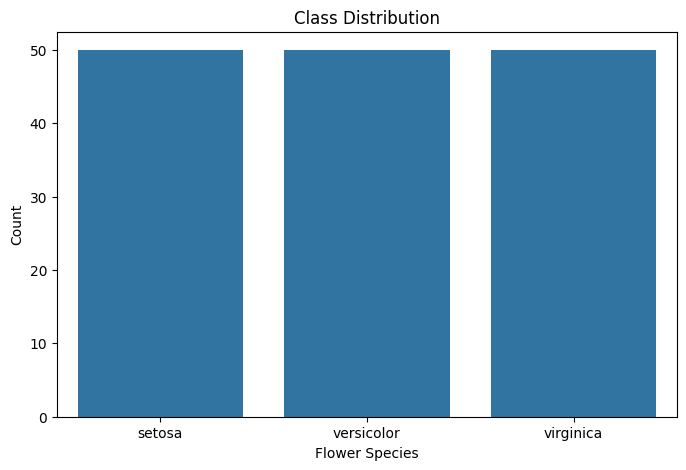

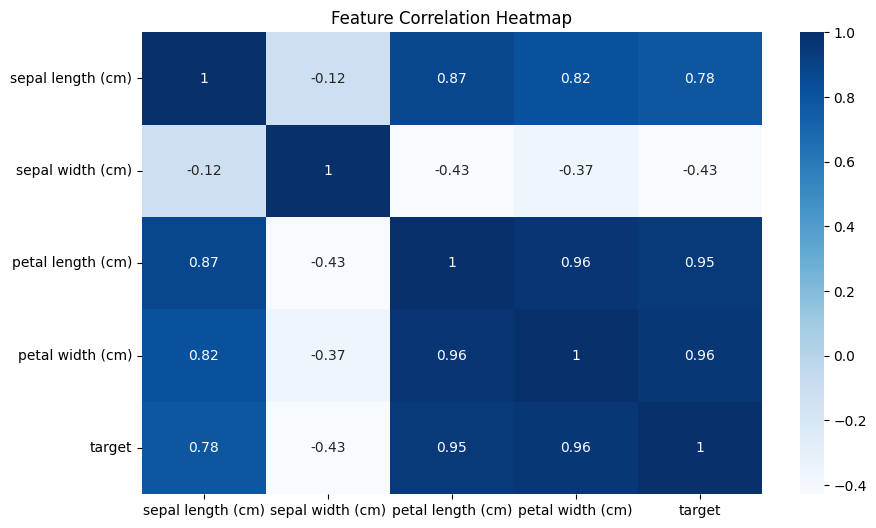

In [4]:
# ============================================================
# STEP 4: VISUALIZE DATASET
# ============================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="species")
plt.title("Class Distribution")
plt.xlabel("Flower Species")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=["species"]).corr(), annot=True, cmap="Blues")
plt.title("Feature Correlation Heatmap")
plt.show()

In [5]:
# ============================================================
# STEP 5: SPLIT DATA INTO TRAINING AND TESTING SETS
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 120
Testing Samples: 30


In [6]:
# ============================================================
# STEP 6: CREATE SMALL AND LARGE MACHINE LEARNING MODELS
# ============================================================

small_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

large_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ))
])

In [7]:
# ============================================================
# STEP 7: TRAIN BOTH MODELS
# ============================================================

small_model.fit(X_train, y_train)
large_model.fit(X_train, y_train)

print("Small Model Training Completed")
print("Large Model Training Completed")

Small Model Training Completed
Large Model Training Completed


In [8]:
# ============================================================
# STEP 8: EVALUATE MODEL PERFORMANCE
# ============================================================

models = {
    "Small Logistic Regression Model": small_model,
    "Large Random Forest Model": large_model
}

results = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results[model_name] = accuracy

    print(f"\n{model_name}")
    print("-" * 50)
    print("Accuracy:", round(accuracy * 100, 2), "%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))


Small Logistic Regression Model
--------------------------------------------------
Accuracy: 93.33 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Large Random Forest Model
--------------------------------------------------
Accuracy: 90.0 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90     

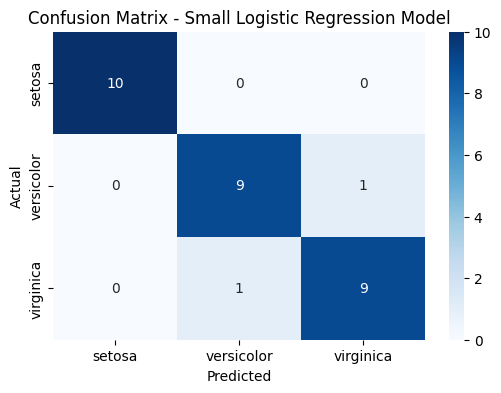

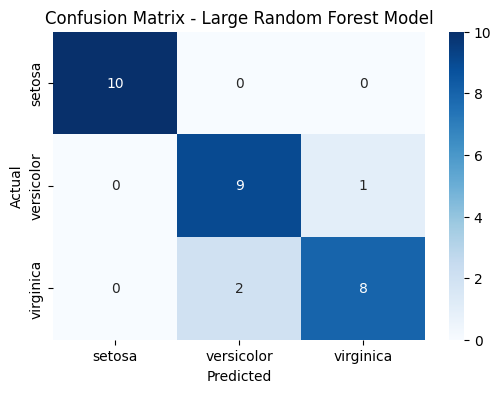

In [9]:
# ============================================================
# STEP 9: DISPLAY CONFUSION MATRIX FOR BOTH MODELS
# ============================================================

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

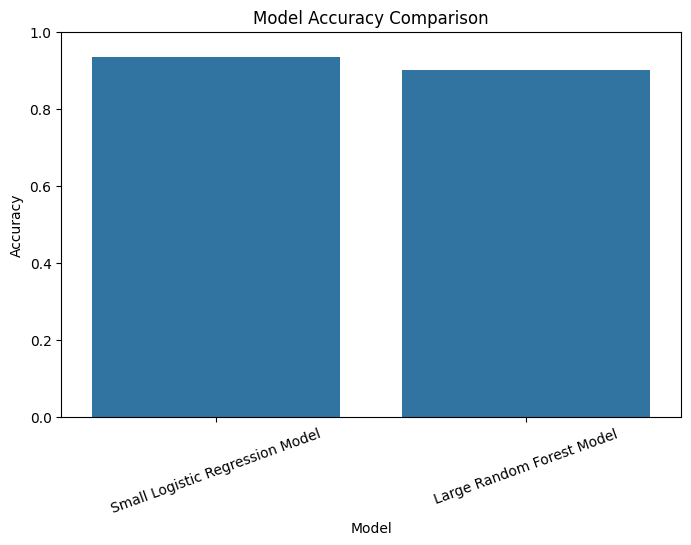

,Model,Accuracy
0,Small Logistic Regression Model,0.933333
1,Large Random Forest Model,0.900000


In [10]:
# ============================================================
# STEP 10: COMPARE MODEL ACCURACY
# ============================================================

results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
})

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

results_df

In [13]:
# ============================================================
# STEP 11: SAVE MODELS AND PROJECT FILES
# ============================================================

joblib.dump(small_model, "models/small_model.pkl")
joblib.dump(large_model, "models/large_model.pkl")

joblib.dump(target_names, "models/target_names.pkl")
joblib.dump(list(X.columns), "models/feature_names.pkl")
joblib.dump(results, "models/model_results.pkl")

df.to_csv("data/iris_dataset.csv", index=False)

print("All models and files saved successfully.")

All models and files saved successfully.


In [14]:
# ============================================================
# STEP 12: TEST SAVED MODEL
# ============================================================

loaded_model = joblib.load("models/small_model.pkl")

sample_input = np.array([[5.1, 3.5, 1.4, 0.2]])
prediction = loaded_model.predict(sample_input)
prediction_name = target_names[prediction[0]]

print("Predicted Class:", prediction_name)

Predicted Class: setosa
